# Figure 2 modularity analysis: ANN vs biological brain

**Core conclusion.** Trained artificial neural networks and biological brains share mesoscale modular organization: FC is modular, and FC-defined modules are preferentially supported by input similarity (IS) rather than by direct structural connectivity (SC) alone.

**Panel logic.**
1. Native modularity: quantify whether FC, IS and SC each contain modular organization.
2. FC-module support: detect modules from FC, then ask whether the same partition explains IS better than SC.
3. Source data are saved as CSV; figures are exported as SVG/PDF/TIFF.

**Efficiency note.** The CNN matrices are large. This notebook builds sparse k-nearest-neighbour graphs from each dense matrix. For preview, large matrices are node-subsampled; for final analysis, set `MAX_NODES_FOR_LARGE = None` if memory/time allow.

In [1]:
from pathlib import Path
import itertools
import warnings

import h5py
import numpy as np
import pandas as pd
import scipy.io
import matplotlib as mpl
import matplotlib.pyplot as plt
import networkx as nx
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')

mpl.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans', 'sans-serif'],
    'svg.fonttype': 'none',
    'pdf.fonttype': 42,
    'font.size': 7,
    'axes.spines.right': False,
    'axes.spines.top': False,
    'axes.linewidth': 0.8,
    'legend.frameon': False,
})

OUTDIR = Path('fig/Figure2_modularity')
OUTDIR.mkdir(parents=True, exist_ok=True)

# ---------- User-adjustable parameters ----------
RANDOM_SEED = 1
KNN_K = 30                  # sparse graph keeps k strongest positive neighbours per node
LARGE_MATRIX_THRESHOLD = 3000
MAX_NODES_FOR_LARGE = 2500  # set to None for full CNN/final run if resources allow
LOUVAIN_REPEATS = 5
N_PARTITION_NULL = 200      # label-preserving null for IS|FC and SC|FC
N_NATIVE_NULL = 0           # optional; set e.g. 50 for slow native-Q nulls
RESOLUTION = 1.0

# ANN matrix folders provided by the user.
ANN_PATHS = {
    'MLP': Path('/mnt/Data16T/Data/haichao/code/AI_connectom/story/story_part2_struc_func/MLP/FC_IS_SC_matrix'),
    'CNN': Path('/mnt/Data16T/Data/haichao/code/AI_connectom/story/story_part2_struc_func/CNN/FC_IS_SC_matrix'),
    'Transformer': Path('/mnt/Data16T/Data/haichao/code/AI_connectom/story/story_part2_struc_func/Transformer/FC_IS_SC_matrix'),
}

# Biological paths follow Bio_FC_IS_SC.ipynb. Edit here if the mount point differs.
BIO_PATHS = {
    'celegans_dir': Path('/mnt/Data16T/Data/haichao/code/AI_connectom/story_bio_analysis/C. elegans/data_uzel2022/'),
    'mouse_fc_csv': Path('/mnt/Data16T/Data/haichao/code/data/FCSCmatrices/mouse_pairwisecorrelation.csv'),
    'mouse_sc_csv': Path('/mnt/Data16T/Data/haichao/code/data/FCSCmatrices/mouse_couplingmatrix.csv'),
    'human_fc_csv': Path('/mnt/Data16T/Data/haichao/code/data/FCSCmatrices/human_N489_pairwisecorrelation.csv'),
    'human_sc_csv': Path('/mnt/Data16T/Data/haichao/code/data/FCSCmatrices/human_N489_couplingmatrix.csv'),
    'marmoset_mat': Path('/nfs/nfs146/Data18Td/Data/haichao/connectome_data/connectome_data.mat'),
}

rng = np.random.default_rng(RANDOM_SEED)


In [2]:
# ---------- Data loading helpers ----------

def as_clean_symmetric_matrix(x, name='matrix', transform='positive'):
    """Return a finite symmetric matrix with zero diagonal.

    transform='positive': negative entries are set to zero.
    transform='abs': absolute values are used; useful for C. elegans FC as in the original Bio notebook.
    transform='none': only finite cleanup and symmetrisation are applied.
    """
    x = np.asarray(x, dtype=np.float32)
    if x.ndim != 2 or x.shape[0] != x.shape[1]:
        raise ValueError(f'{name} must be square, got {x.shape}')
    x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)
    x = 0.5 * (x + x.T)
    if transform == 'positive':
        x = np.maximum(x, 0)
    elif transform == 'abs':
        x = np.abs(x)
    elif transform == 'none':
        pass
    else:
        raise ValueError(f'Unknown transform: {transform}')
    np.fill_diagonal(x, 0)
    return x


def cosine_similarity_from_inputs(sc):
    sc = np.asarray(sc, dtype=np.float32)
    sc = np.nan_to_num(sc, nan=0.0, posinf=0.0, neginf=0.0)
    norm = np.linalg.norm(sc, axis=0)
    norm[norm == 0] = 1e-12
    z = sc / norm[None, :]
    sim = z.T @ z
    np.fill_diagonal(sim, 0)
    return sim.astype(np.float32, copy=False)


def maybe_subsample_matrices(mats, max_nodes=MAX_NODES_FOR_LARGE, threshold=LARGE_MATRIX_THRESHOLD, seed=RANDOM_SEED):
    n = mats[0].shape[0]
    if max_nodes is None or n <= threshold or n <= max_nodes:
        return mats, np.arange(n), False
    local_rng = np.random.default_rng(seed)
    idx = np.sort(local_rng.choice(n, size=max_nodes, replace=False))
    sub = [m[np.ix_(idx, idx)] for m in mats]
    return sub, idx, True


def load_ann_dataset(system, folder):
    fc = np.load(folder / 'FC_matrix_crosslayer.npy', mmap_mode='r')
    is_ = np.load(folder / 'IS_matrix_crosslayer.npy', mmap_mode='r')
    sc = np.load(folder / 'SC_matrix_crosslayer.npy', mmap_mode='r')
    if not (fc.shape == is_.shape == sc.shape):
        raise ValueError(f'{system}: FC/IS/SC shapes do not match: {fc.shape}, {is_.shape}, {sc.shape}')
    mats, node_idx, sampled = maybe_subsample_matrices([fc, is_, sc])
    fc = as_clean_symmetric_matrix(mats[0], f'{system} FC', transform='positive')
    is_ = as_clean_symmetric_matrix(mats[1], f'{system} IS', transform='positive')
    sc = as_clean_symmetric_matrix(mats[2], f'{system} SC', transform='positive')
    return {'group': 'ANN', 'system': system, 'replicate': 'final', 'FC': fc, 'IS': is_, 'SC': sc, 'node_idx': node_idx, 'sampled': sampled}


def get_matlab_string(f, ref):
    obj = f[ref]
    val = np.array(obj).flatten()
    while len(val) > 0 and isinstance(val[0], h5py.h5r.Reference):
        obj = f[val[0]]
        val = np.array(obj).flatten()
    return ''.join(chr(int(c)) for c in val)


def load_celegans_dataset(folder):
    with h5py.File(folder / 'Neuro279_EJ.mat', 'r') as f:
        neuro279_ej = np.array(f['Neuro279_EJ']).T
    with h5py.File(folder / 'Neuro279_Syn.mat', 'r') as f:
        neuro279_syn = np.array(f['Neuro279_Syn']).T
    with h5py.File(folder / 'Order279.mat', 'r') as f:
        refs = np.array(f['Order279']).flatten()
        order279_names = [get_matlab_string(f, ref) for ref in refs]

    corr_matrices = []
    with h5py.File(folder / 'Uzel_WT.mat', 'r') as f:
        derivs_refs = np.array(f['Uzel_WT']['derivatives']).flatten()
        ids_refs = np.array(f['Uzel_WT']['IDs']).flatten()
        for d_ref, id_ref in zip(derivs_refs, ids_refs):
            dataset = np.array(f[d_ref]).T
            dataset_id_refs = np.array(f[id_ref]).flatten()
            dataset_names = [get_matlab_string(f, r) for r in dataset_id_refs]
            corr_279 = np.full((279, 279), np.nan, dtype=np.float32)
            valid_global_idx, valid_local_idx = [], []
            for i, name in enumerate(order279_names):
                if name in dataset_names:
                    valid_global_idx.append(i)
                    valid_local_idx.append(dataset_names.index(name))
            valid_data = dataset[:, valid_local_idx]
            valid_corr = np.nan_to_num(np.corrcoef(valid_data, rowvar=False))
            for r_idx, global_r in enumerate(valid_global_idx):
                for c_idx, global_c in enumerate(valid_global_idx):
                    corr_279[global_r, global_c] = valid_corr[r_idx, c_idx]
            corr_matrices.append(corr_279)
    fc = np.nanmean(corr_matrices, axis=0)
    sc = (neuro279_syn + neuro279_ej > 0).astype(np.float32)
    is_ = cosine_similarity_from_inputs(sc)
    return {'group': 'Brain', 'system': 'C. elegans', 'replicate': 'WT', 'FC': as_clean_symmetric_matrix(fc, 'C. elegans FC', 'abs'), 'IS': as_clean_symmetric_matrix(is_, 'C. elegans IS'), 'SC': as_clean_symmetric_matrix(sc, 'C. elegans SC'), 'node_idx': np.arange(fc.shape[0]), 'sampled': False}


def load_biological_datasets(paths=BIO_PATHS):
    datasets = []
    # C. elegans
    if paths['celegans_dir'].exists():
        datasets.append(load_celegans_dataset(paths['celegans_dir']))
    else:
        print(f"Skip C. elegans: folder not found: {paths['celegans_dir']}")

    # Mouse: keep left and right hemispheres as two replicates.
    if paths['mouse_fc_csv'].exists() and paths['mouse_sc_csv'].exists():
        fc_mouse = pd.read_csv(paths['mouse_fc_csv'], index_col=0)
        sc_mouse = pd.read_csv(paths['mouse_sc_csv'], index_col=0)
        for hemi in ['left_', 'right_']:
            fc = fc_mouse.filter(like=hemi, axis=0).filter(like=hemi, axis=1).values
            sc = sc_mouse.filter(like=hemi, axis=0).filter(like=hemi, axis=1).values
            is_ = cosine_similarity_from_inputs(sc)
            datasets.append({'group': 'Brain', 'system': 'Mouse', 'replicate': hemi.replace('_', ''), 'FC': as_clean_symmetric_matrix(fc, 'Mouse FC'), 'IS': as_clean_symmetric_matrix(is_, 'Mouse IS'), 'SC': as_clean_symmetric_matrix(sc, 'Mouse SC'), 'node_idx': np.arange(fc.shape[0]), 'sampled': False})
    else:
        print('Skip Mouse: CSV files not found.')

    # Human.
    if paths['human_fc_csv'].exists() and paths['human_sc_csv'].exists():
        fc = pd.read_csv(paths['human_fc_csv'], index_col=0).values
        sc = pd.read_csv(paths['human_sc_csv'], index_col=0).values
        is_ = cosine_similarity_from_inputs(sc)
        datasets.append({'group': 'Brain', 'system': 'Human', 'replicate': 'N489', 'FC': as_clean_symmetric_matrix(fc, 'Human FC'), 'IS': as_clean_symmetric_matrix(is_, 'Human IS'), 'SC': as_clean_symmetric_matrix(sc, 'Human SC'), 'node_idx': np.arange(fc.shape[0]), 'sampled': False})
    else:
        print('Skip Human: CSV files not found.')

    # Marmoset.
    if paths['marmoset_mat'].exists():
        data = scipy.io.loadmat(paths['marmoset_mat'])
        fc = data['MBMv4_FC']
        sc = data['MBMv4_SC']
        is_ = cosine_similarity_from_inputs(sc)
        datasets.append({'group': 'Brain', 'system': 'Marmoset', 'replicate': 'MBMv4', 'FC': as_clean_symmetric_matrix(fc, 'Marmoset FC'), 'IS': as_clean_symmetric_matrix(is_, 'Marmoset IS'), 'SC': as_clean_symmetric_matrix(sc, 'Marmoset SC'), 'node_idx': np.arange(fc.shape[0]), 'sampled': False})
    else:
        print(f"Skip Marmoset: MAT file not found: {paths['marmoset_mat']}")
    return datasets


def load_all_datasets():
    datasets = []
    for system, folder in ANN_PATHS.items():
        if folder.exists():
            print(f'Loading ANN: {system}')
            datasets.append(load_ann_dataset(system, folder))
        else:
            print(f'Skip {system}: folder not found: {folder}')
    datasets.extend(load_biological_datasets())
    return datasets


datasets = load_all_datasets()
[(d['group'], d['system'], d['replicate'], d['FC'].shape, d['sampled']) for d in datasets]


Loading ANN: MLP
Loading ANN: CNN
Loading ANN: Transformer


[('ANN', 'MLP', 'final', (200, 200), False),
 ('ANN', 'CNN', 'final', (2500, 2500), True),
 ('ANN', 'Transformer', 'final', (256, 256), False),
 ('Brain', 'C. elegans', 'WT', (279, 279), False),
 ('Brain', 'Mouse', 'left', (3502, 3502), False),
 ('Brain', 'Mouse', 'right', (3502, 3502), False),
 ('Brain', 'Human', 'N489', (489, 489), False),
 ('Brain', 'Marmoset', 'MBMv4', (192, 192), False)]

In [3]:
# ---------- Modularity calculation ----------

def knn_graph_from_matrix(mat, k=KNN_K, name='matrix'):
    """Build an undirected weighted graph using the top-k positive neighbours of each node.

    This avoids materialising a dense complete graph for large matrices such as CNN.
    Edge weights are the original matrix values. Directed kNN choices are merged by keeping
    the larger weight when an edge is selected from either endpoint.
    """
    mat = np.asarray(mat)
    n = mat.shape[0]
    G = nx.Graph()
    G.add_nodes_from(range(n))
    k_eff = min(k, n - 1)
    if k_eff <= 0:
        return G

    for i in range(n):
        row = np.asarray(mat[i], dtype=np.float32).copy()
        row[i] = 0.0
        pos = row > 0
        n_pos = int(pos.sum())
        if n_pos == 0:
            continue
        if n_pos <= k_eff:
            nbrs = np.flatnonzero(pos)
        else:
            idx = np.argpartition(row, -k_eff)[-k_eff:]
            nbrs = idx[row[idx] > 0]
        for j in nbrs:
            if i == j:
                continue
            w = float(row[j])
            if G.has_edge(i, int(j)):
                if w > G[i][int(j)]['weight']:
                    G[i][int(j)]['weight'] = w
            else:
                G.add_edge(i, int(j), weight=w)
    print(f'{name}: n={G.number_of_nodes()}, edges={G.number_of_edges()}')
    return G


def best_louvain_partition(G, repeats=LOUVAIN_REPEATS, resolution=RESOLUTION, seed=RANDOM_SEED):
    if G.number_of_edges() == 0:
        return [set(G.nodes())], np.nan
    best_comms, best_q = None, -np.inf
    for r in range(repeats):
        local_seed = seed + r
        if hasattr(nx.community, 'louvain_communities'):
            comms = nx.community.louvain_communities(G, weight='weight', resolution=resolution, seed=local_seed)
        else:
            comms = nx.community.greedy_modularity_communities(G, weight='weight', resolution=resolution)
        q = nx.community.modularity(G, comms, weight='weight', resolution=resolution)
        if q > best_q:
            best_comms, best_q = comms, q
    return [set(c) for c in best_comms], float(best_q)


def partition_to_labels(communities, n):
    labels = np.full(n, -1, dtype=int)
    for ci, comm in enumerate(communities):
        labels[list(comm)] = ci
    if np.any(labels < 0):
        missing = np.flatnonzero(labels < 0)
        labels[missing] = np.arange(labels.max() + 1, labels.max() + 1 + len(missing))
    return labels


def labels_to_communities(labels):
    labels = np.asarray(labels)
    return [set(np.flatnonzero(labels == lab).tolist()) for lab in np.unique(labels)]


def modularity_for_labels(G, labels, resolution=RESOLUTION):
    if G.number_of_edges() == 0:
        return np.nan
    return float(nx.community.modularity(G, labels_to_communities(labels), weight='weight', resolution=resolution))


def shuffled_partition_null(G, labels, n_null=N_PARTITION_NULL, seed=RANDOM_SEED, resolution=RESOLUTION):
    local_rng = np.random.default_rng(seed)
    labels = np.asarray(labels).copy()
    qs = np.empty(n_null, dtype=float)
    for i in range(n_null):
        shuffled = local_rng.permutation(labels)
        qs[i] = modularity_for_labels(G, shuffled, resolution=resolution)
    return qs


def zscore_from_null(obs, null_values):
    null_values = np.asarray(null_values, dtype=float)
    sd = np.nanstd(null_values, ddof=1)
    if not np.isfinite(sd) or sd == 0:
        return np.nan
    return float((obs - np.nanmean(null_values)) / sd)


def native_weight_shuffle_null(G, repeats=50, louvain_repeats=3, seed=RANDOM_SEED, resolution=RESOLUTION):
    """Optional slow null: shuffle edge weights on the same topology and re-detect communities."""
    if repeats <= 0 or G.number_of_edges() == 0:
        return np.array([], dtype=float)
    local_rng = np.random.default_rng(seed)
    edges = list(G.edges())
    weights = np.array([G[u][v]['weight'] for u, v in edges], dtype=float)
    qs = []
    for r in range(repeats):
        H = nx.Graph()
        H.add_nodes_from(G.nodes())
        shuffled = local_rng.permutation(weights)
        H.add_weighted_edges_from([(u, v, float(w)) for (u, v), w in zip(edges, shuffled)])
        _, q = best_louvain_partition(H, repeats=louvain_repeats, resolution=resolution, seed=seed + 10000 + r)
        qs.append(q)
    return np.array(qs, dtype=float)


def analyse_one_dataset(d):
    graphs = {
        'FC': knn_graph_from_matrix(d['FC'], KNN_K, f"{d['system']} {d['replicate']} FC"),
        'IS': knn_graph_from_matrix(d['IS'], KNN_K, f"{d['system']} {d['replicate']} IS"),
        'SC': knn_graph_from_matrix(d['SC'], KNN_K, f"{d['system']} {d['replicate']} SC"),
    }

    rows = []
    partitions = {}
    for mat_name, G in graphs.items():
        comms, q = best_louvain_partition(G)
        labels = partition_to_labels(comms, G.number_of_nodes())
        partitions[mat_name] = {'communities': comms, 'labels': labels, 'Q': q}
        native_null = native_weight_shuffle_null(G, repeats=N_NATIVE_NULL, seed=RANDOM_SEED + len(rows))
        rows.append({
            'group': d['group'], 'system': d['system'], 'replicate': d['replicate'],
            'analysis': 'native_modularity', 'matrix': mat_name, 'target_graph': mat_name,
            'Q': q, 'Z': zscore_from_null(q, native_null) if len(native_null) else np.nan,
            'n_nodes': G.number_of_nodes(), 'n_edges': G.number_of_edges(),
            'n_modules': len(comms), 'module_sizes': ';'.join(map(str, sorted([len(c) for c in comms], reverse=True))),
            'sampled_large_matrix': d['sampled'], 'k_nn': KNN_K,
        })

    fc_labels = partitions['FC']['labels']
    for target in ['FC', 'IS', 'SC']:
        G = graphs[target]
        q_obs = modularity_for_labels(G, fc_labels)
        q_null = shuffled_partition_null(G, fc_labels, n_null=N_PARTITION_NULL, seed=RANDOM_SEED + 123)
        rows.append({
            'group': d['group'], 'system': d['system'], 'replicate': d['replicate'],
            'analysis': 'FC_partition_support', 'matrix': f'{target}|FC_modules', 'target_graph': target,
            'Q': q_obs, 'Z': zscore_from_null(q_obs, q_null),
            'null_mean': float(np.nanmean(q_null)), 'null_sd': float(np.nanstd(q_null, ddof=1)),
            'n_nodes': G.number_of_nodes(), 'n_edges': G.number_of_edges(),
            'n_modules': partitions['FC']['labels'].max() + 1,
            'module_sizes': ';'.join(map(str, sorted(np.bincount(fc_labels), reverse=True))),
            'sampled_large_matrix': d['sampled'], 'k_nn': KNN_K,
        })
    return pd.DataFrame(rows), partitions


all_rows = []
all_partitions = {}
for d in tqdm(datasets, desc='Datasets'):
    df_one, part_one = analyse_one_dataset(d)
    all_rows.append(df_one)
    all_partitions[(d['group'], d['system'], d['replicate'])] = part_one

result_df = pd.concat(all_rows, ignore_index=True) if all_rows else pd.DataFrame()
result_csv = OUTDIR / 'Figure2_modularity_source_data.csv'
result_df.to_csv(result_csv, index=False)
result_df


Datasets:   0%|          | 0/8 [00:00<?, ?it/s]

MLP final FC: n=200, edges=3707
MLP final IS: n=200, edges=3904
MLP final SC: n=200, edges=3676
CNN final FC: n=2500, edges=47314
CNN final IS: n=2500, edges=46898
CNN final SC: n=2500, edges=60339
Transformer final FC: n=256, edges=4784
Transformer final IS: n=256, edges=4913
Transformer final SC: n=256, edges=4155
C. elegans WT FC: n=279, edges=1346
C. elegans WT IS: n=279, edges=4993
C. elegans WT SC: n=279, edges=2261
Mouse left FC: n=3502, edges=66767
Mouse left IS: n=3502, edges=59108
Mouse left SC: n=3502, edges=93314
Mouse right FC: n=3502, edges=66514
Mouse right IS: n=3502, edges=59071
Mouse right SC: n=3502, edges=93244
Human N489 FC: n=489, edges=9637
Human N489 IS: n=489, edges=8725
Human N489 SC: n=489, edges=8954
Marmoset MBMv4 FC: n=192, edges=4377
Marmoset MBMv4 IS: n=192, edges=3342
Marmoset MBMv4 SC: n=192, edges=3472


,group,system,replicate,analysis,matrix,target_graph,Q,Z,n_nodes,n_edges,n_modules,module_sizes,sampled_large_matrix,k_nn,null_mean,null_sd
0,ANN,MLP,final,native_modularity,FC,FC,0.498301,NaN,200,3707,6,55;53;45;45;1;1,False,30,NaN,NaN
1,ANN,MLP,final,native_modularity,IS,IS,0.421478,NaN,200,3904,4,57;53;48;42,False,30,NaN,NaN
2,ANN,MLP,final,native_modularity,SC,SC,0.286935,NaN,200,3676,4,54;49;49;48,False,30,NaN,NaN
3,ANN,MLP,final,FC_partition_support,FC|FC_modules,FC,0.498301,77.959826,200,3707,6,55;53;45;45;1;1,False,30,-0.003975,0.006443
4,ANN,MLP,final,FC_partition_support,IS|FC_modules,IS,0.395654,55.087213,200,3904,6,55;53;45;45;1;1,False,30,-0.004041,0.007256
5,ANN,MLP,final,FC_partition_support,SC|FC_modules,SC,0.254773,30.162940,200,3676,6,55;53;45;45;1;1,False,30,-0.003891,0.008576
6,ANN,CNN,final,native_modularity,FC,FC,0.725337,NaN,2500,47314,51,313;297;222;197;196;188;180;171;160;130;124;10...,True,30,NaN,NaN
7,ANN,CNN,final,native_modularity,IS,IS,0.689943,NaN,2500,46898,48,301;280;279;269;262;245;233;187;158;132;117;1;...,True,30,NaN,NaN
8,ANN,CNN,final,native_modularity,SC,SC,0.575528,NaN,2500,60339,5,634;585;558;534;189,True,30,NaN,NaN
9,ANN,CNN,final,FC_partition_support,FC|FC_modules,FC,0.725337,526.395720,2500,47314,51,313;297;222;197;196;188;180;171;160;130;124;10...,True,30,-0.000631,0.001379


In [6]:
# ---------- Figure plotting ----------

PALETTE = {
    'FC': '#2E8B57',
    'IS': '#E68632',
    'SC': '#6B7280',
    'FC|FC_modules': '#2E8B57',
    'IS|FC_modules': '#E68632',
    'SC|FC_modules': '#6B7280',
}
SYSTEM_ORDER = ['MLP', 'CNN', 'Transformer', 'C. elegans', 'Mouse', 'Marmoset', 'Human']


def jitter_positions(x, n, width=0.16):
    if n == 1:
        return np.array([x])
    return x + np.linspace(-width, width, n)


def save_pub_py(fig, filename, dpi=600):
    fig.savefig(f'{filename}.svg', bbox_inches='tight')
    fig.savefig(f'{filename}.pdf', bbox_inches='tight')
    fig.savefig(f'{filename}.tiff', dpi=dpi, bbox_inches='tight')


def plot_figure2_modularity(result_df, y_metric='Z'):
    if result_df.empty:
        raise ValueError('result_df is empty. Run the analysis cell first.')
    # If native Z is not computed, panel a falls back to raw Q.
    native_metric = y_metric
    native = result_df[result_df['analysis'] == 'native_modularity'].copy()
    if native_metric == 'Z' and native['Z'].isna().all():
        native_metric = 'Q'
    support = result_df[(result_df['analysis'] == 'FC_partition_support') & (result_df['target_graph'].isin(['IS', 'SC']))].copy()

    systems = [s for s in SYSTEM_ORDER if s in result_df['system'].unique()]
    xbase = {s: i for i, s in enumerate(systems)}

    fig, axes = plt.subplots(1, 2, figsize=(7.2, 2.6), gridspec_kw={'width_ratios': [1.15, 1.0]})
    ax = axes[0]
    offsets = {'FC': -0.18, 'IS': 0.0, 'SC': 0.18}
    for matrix in ['FC', 'IS', 'SC']:
        sub = native[native['matrix'] == matrix]
        for s in systems:
            vals = sub.loc[sub['system'] == s, native_metric].dropna().values
            if len(vals) == 0:
                continue
            xs = jitter_positions(xbase[s] + offsets[matrix], len(vals), width=0.035)
            ax.scatter(xs, vals, s=18, color=PALETTE[matrix], edgecolor='white', linewidth=0.3, zorder=3, label=matrix if s == systems[0] else None)
            ax.plot([xbase[s] + offsets[matrix] - 0.055, xbase[s] + offsets[matrix] + 0.055], [np.mean(vals), np.mean(vals)], color=PALETTE[matrix], lw=1.2)
    ax.axhline(0, color='0.75', lw=0.8, zorder=1)
    ax.set_xticks(range(len(systems)))
    ax.set_xticklabels(systems, rotation=35, ha='right')
    ax.set_ylabel('Native modularity, ' + native_metric)
    ax.set_title('Native modularity')
    ax.legend(loc='upper left', ncol=3, handletextpad=0.4, columnspacing=0.8)

    ax = axes[1]
    for s in systems:
        sub_s = support[support['system'] == s]
        reps = sorted(sub_s['replicate'].unique())
        for rep in reps:
            sub_r = sub_s[sub_s['replicate'] == rep]
            vals = {row['target_graph']: row[y_metric] for _, row in sub_r.iterrows()}
            if 'IS' in vals and 'SC' in vals:
                x1, x2 = xbase[s] - 0.08, xbase[s] + 0.08
                ax.plot([x1, x2], [vals['IS'], vals['SC']], color='0.78', lw=0.8, zorder=1)
                ax.scatter([x1], [vals['IS']], s=20, color=PALETTE['IS'], edgecolor='white', linewidth=0.3, zorder=2, label='IS under FC modules' if s == systems[0] and rep == reps[0] else None)
                ax.scatter([x2], [vals['SC']], s=20, color=PALETTE['SC'], edgecolor='white', linewidth=0.3, zorder=2, label='SC under FC modules' if s == systems[0] and rep == reps[0] else None)
    ax.axhline(0, color='0.75', lw=0.8, zorder=1)
    ax.set_xticks(range(len(systems)))
    ax.set_xticklabels(systems, rotation=35, ha='right')
    ax.set_ylabel('FC-module support, Z')
    ax.set_title('FC modules are preferentially supported by IS')
    ax.legend(loc='upper left', handletextpad=0.4)

    for label, ax in zip(['g', 'h'], axes):
        ax.text(-0.12, 1.05, label, transform=ax.transAxes, fontsize=9, fontweight='bold', va='bottom')

    fig.tight_layout(w_pad=1.0)
    return fig


# Diagnostic Q/Z plot retained for optional inspection.
# For the main Figure 2 modularity panels, run the optimized network + support cell below.
# fig = plot_figure2_modularity(result_df, y_metric='Z')
# save_pub_py(fig, OUTDIR / 'Figure2_modularity_diagnostic_QZ')
# plt.show()


## Optimized Figure 2 panels: network examples + modularity bars + FC-module overlap radar

This is the recommended main-figure version. It avoids repeating heatmaps and uses two direct readouts:

1. **Network examples** for MLP and Mouse. Nodes are placed and coloured by FC-derived modules; FC, IS and SC are shown on the same FC-derived layout. Display parameters are system-specific because MLP and Mouse need different graph densities.
2. **Modularity bars** beside the network examples. These show Louvain modularity Q for the displayed FC, IS and SC graphs.
3. **All-system radar plot**. FC modules are held fixed; the two lines show how well IS or SC weights discriminate within-FC-module from between-module node pairs (AUC).

The key comparison is whether IS supports the fixed FC modules more strongly than SC does across ANN and Brain systems.

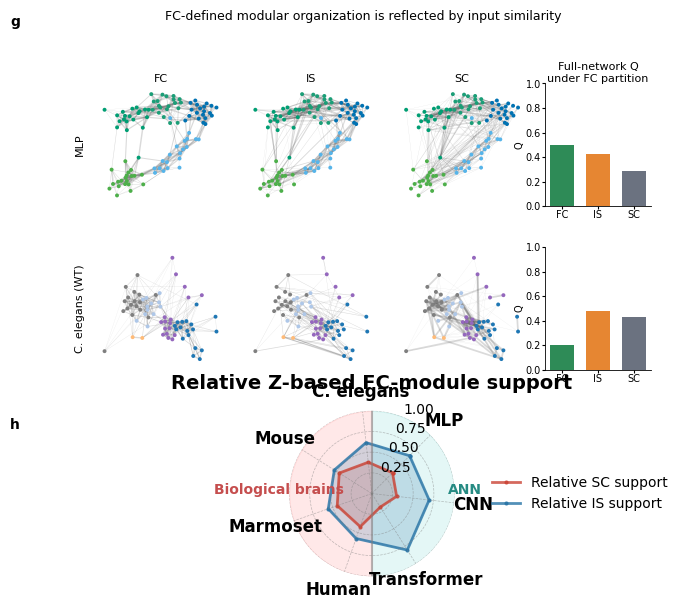

Saved relative Z-based FC-module support source data: fig/Figure2_modularity/Figure2_relative_Z_FC_module_support_source_data.csv
Saved optimized figure files: fig/Figure2_modularity/Figure2_modularity_network_support.[svg/pdf/tiff]


,group,system,replicate,matrix,Q_FC_partition,Z_FC_partition,null_mean,null_sd,n_nodes,n_edges,...,sampled_large_matrix,k_nn,Z_IS,Z_SC,normalized_Z_contrast_IS_minus_SC,relative_IS_support,relative_SC_support,relative_z_support,relative_support_sum,IS_Z_greater_than_SC
0,ANN,MLP,final,IS,0.395654,55.087213,-0.004041,0.007256,200,3904,...,False,30,55.087213,30.162940,0.292366,0.646183,0.353817,0.646183,1.0,True
1,ANN,MLP,final,SC,0.254773,30.162940,-0.003891,0.008576,200,3676,...,False,30,55.087213,30.162940,0.292366,0.646183,0.353817,0.353817,1.0,True
2,ANN,CNN,final,IS,0.572494,402.128237,-0.000549,0.001425,2500,46898,...,True,30,402.128237,174.195059,0.395495,0.697748,0.302252,0.697748,1.0,True
3,ANN,CNN,final,SC,0.324204,174.195059,-0.000863,0.001866,2500,60339,...,True,30,402.128237,174.195059,0.395495,0.697748,0.302252,0.302252,1.0,True
4,ANN,Transformer,final,IS,0.354828,71.543438,-0.003234,0.005005,256,4913,...,False,30,71.543438,17.162459,0.613048,0.806524,0.193476,0.806524,1.0,True
5,ANN,Transformer,final,SC,0.157556,17.162459,-0.002898,0.009349,256,4155,...,False,30,71.543438,17.162459,0.613048,0.806524,0.193476,0.193476,1.0,True
6,Brain,C. elegans,WT,IS,0.013936,9.124999,-0.004240,0.001992,279,4993,...,False,30,9.124999,5.606198,0.238867,0.619434,0.380566,0.619434,1.0,True
7,Brain,C. elegans,WT,SC,0.011478,5.606198,-0.005127,0.002962,279,2261,...,False,30,9.124999,5.606198,0.238867,0.619434,0.380566,0.380566,1.0,True
8,Brain,Mouse,left,IS,0.773676,708.014376,-0.000211,0.001093,3502,59108,...,False,30,708.014376,604.086201,0.079207,0.539604,0.460396,0.539604,1.0,True
9,Brain,Mouse,left,SC,0.604185,604.086201,-0.000545,0.001001,3502,93314,...,False,30,708.014376,604.086201,0.079207,0.539604,0.460396,0.460396,1.0,True


In [15]:
SYSTEM_MODULE_COLORS = {
    # Human
    'Mouse': [
        '#D55E00',  # orange-red
        '#E69F00',  # orange
        '#CC79A7',  # reddish purple
        '#A65628',  # brown
        '#E7298A',  # magenta
        '#F46D43',
        '#FDAE61',
        '#F0C808',  # yellow
    ],

    # MLP：冷色系
    'MLP': [
        '#0072B2',  # blue
        '#56B4E9',  # light blue
        '#009E73',  # green
        '#1B9E77',  # teal
        '#4DAF4A',  # green
        '#6A3D9A',  # purple-blue
        '#3288BD',
        '#66C2A5',
    ],
}

PALETTE = {
    'FC': '#2E8B57',
    'IS': '#E68632',
    'SC': '#6B7280',
    'FC|FC_modules': '#2E8B57',
    'IS|FC_modules': '#E68632',
    'SC|FC_modules': '#6B7280',
}


def save_pub_py(fig, filename, dpi=600):
    fig.savefig(f'{filename}.svg', bbox_inches='tight')
    fig.savefig(f'{filename}.pdf', bbox_inches='tight')
    fig.savefig(f'{filename}.tiff', dpi=dpi, bbox_inches='tight')

def module_palette(labels, system='default'):
    """Assign system-specific categorical colors to FC-derived modules."""
    labs = np.unique(labels)

    if system in SYSTEM_MODULE_COLORS:
        colors = SYSTEM_MODULE_COLORS[system]
        return {
            lab: colors[i % len(colors)]
            for i, lab in enumerate(labs)
        }

    # Other systems retain the original tab20 palette
    cmap = plt.get_cmap('tab20')
    return {
        lab: cmap(i % 20)
        for i, lab in enumerate(labs)
    }

# ---------- Optimized main Figure 2 modularity panels ----------
from matplotlib.gridspec import GridSpec

# NETWORK_EXAMPLE_SYSTEMS = [('MLP', None), ('Human', 'N489')]
# NETWORK_EXAMPLE_SYSTEMS = [('MLP', None), ('Marmoset', 'MBMv4')]
# NETWORK_EXAMPLE_SYSTEMS = [('MLP', None), ('Mouse', 'left')]
NETWORK_EXAMPLE_SYSTEMS = [('MLP', None), ('C. elegans', 'WT')]

# Display-only parameters are system-specific. Set network_layout independently
# to 'spring' or 'kamada_kawai'; FC-derived coordinates are reused for FC/IS/SC.
NETWORK_DISPLAY_PARAMS = {
    'default': dict(
        edge_percent=0.08, graph_mode='knn', k_per_node=6,
        max_nodes=140, max_modules=5, hide_fc_isolates=True,
        network_layout='spring', layout_k=0.55,
    ),
    'MLP': dict(
        edge_percent=0.08, graph_mode='knn', k_per_node=6,
        max_nodes=100, max_modules=5, hide_fc_isolates=True,
        network_layout='spring', layout_k=0.3,
    ),
    'Human': dict(
        edge_percent=0.08, graph_mode='knn', k_per_node=8,
        max_nodes=140, max_modules=5, hide_fc_isolates=True,
        network_layout='kamada_kawai', layout_k=0.12,
    ),
    'Marmoset': dict(
        edge_percent=0.08, graph_mode='knn', k_per_node=6,
        max_nodes=100, max_modules=5, hide_fc_isolates=True,
        network_layout='kamada_kawai', layout_k=0.12,
    ),
    'Mouse': dict(
        edge_percent=0.08, graph_mode='knn', k_per_node=8,
        max_nodes=100, max_modules=5, hide_fc_isolates=True,
        network_layout='kamada_kawai', layout_k=0.12,
    ),
    'C. elegans': dict(
        edge_percent=0.08, graph_mode='knn', k_per_node=6,
        max_nodes=100, max_modules=5, hide_fc_isolates=True,
        network_layout='kamada_kawai', layout_k=0.12,
    )
}


def validate_edge_percent(edge_percent, name='edge_percent'):
    if isinstance(edge_percent, (tuple, list)):
        raise ValueError(f"{name} must be a float between 0 and 1. Did you write 0,3 instead of 0.3?")
    edge_percent = float(edge_percent)
    if not (0 < edge_percent <= 1):
        raise ValueError(f'{name} must be in (0, 1], got {edge_percent}')
    return edge_percent


def positive_upper_edges(mat, edge_percent=0.05):
    """Return strongest positive upper-triangle edges as i, j, weight arrays."""
    edge_percent = validate_edge_percent(edge_percent)
    mat = np.asarray(mat)
    iu, ju = np.triu_indices(mat.shape[0], k=1)
    vals = mat[iu, ju]
    valid = np.isfinite(vals) & (vals > 0)
    iu, ju, vals = iu[valid], ju[valid], vals[valid]
    if len(vals) == 0:
        return iu[:0], ju[:0], vals[:0]
    n_keep = max(1, int(np.ceil(len(vals) * edge_percent)))
    if n_keep < len(vals):
        keep = np.argpartition(vals, -n_keep)[-n_keep:]
        keep = keep[np.argsort(vals[keep])[::-1]]
    else:
        keep = np.argsort(vals)[::-1]
    return iu[keep], ju[keep], vals[keep].astype(float)


def top_percent_graph_from_matrix(mat, edge_percent=0.05):
    n = mat.shape[0]
    i, j, w = positive_upper_edges(mat, edge_percent=edge_percent)
    G = nx.Graph()
    G.add_nodes_from(range(n))
    G.add_weighted_edges_from([(int(a), int(b), float(c)) for a, b, c in zip(i, j, w)])
    return G


def display_knn_graph_from_matrix(mat, k=6):
    """Display-only graph: keep each node's k strongest positive neighbours.

    This prevents the visual artefact where a global top-percent threshold leaves many
    nodes isolated, especially in small or strongly hub-like matrices such as MLP.
    """
    mat = np.asarray(mat)
    n = mat.shape[0]
    G = nx.Graph()
    G.add_nodes_from(range(n))
    k_eff = max(1, min(int(k), n - 1))
    for i in range(n):
        row = np.asarray(mat[i], dtype=float).copy()
        row[i] = 0.0
        pos = row > 0
        if not np.any(pos):
            continue
        if int(pos.sum()) <= k_eff:
            nbrs = np.flatnonzero(pos)
        else:
            nbrs = np.argpartition(row, -k_eff)[-k_eff:]
            nbrs = nbrs[row[nbrs] > 0]
        for j in nbrs:
            w = float(row[j])
            if G.has_edge(i, int(j)):
                G[i][int(j)]['weight'] = max(G[i][int(j)]['weight'], w)
            else:
                G.add_edge(i, int(j), weight=w)
    return G


def display_graph_from_matrix(mat, mode='knn', edge_percent=0.08, k=6):
    if mode == 'knn':
        return display_knn_graph_from_matrix(mat, k=k)
    if mode == 'percent':
        return top_percent_graph_from_matrix(mat, edge_percent=edge_percent)
    raise ValueError("graph_mode must be 'knn' or 'percent'")


def get_dataset_by_system(datasets, system, replicate=None):
    candidates = [d for d in datasets if d['system'] == system]
    if replicate is not None:
        preferred = [d for d in candidates if str(d['replicate']).lower() == str(replicate).lower()]
        if preferred:
            return preferred[0]
    if not candidates:
        return None
    return candidates[0]


def select_display_nodes_from_modules(labels, max_nodes=140, max_modules=5, seed=RANDOM_SEED):
    labels = np.asarray(labels)
    n = len(labels)
    if n <= max_nodes:
        return np.arange(n)
    local_rng = np.random.default_rng(seed)
    sizes = pd.Series(labels).value_counts().sort_values(ascending=False)
    keep_modules = sizes.index[:max_modules].to_numpy()
    per_module = max(8, max_nodes // len(keep_modules))
    selected = []
    for lab in keep_modules:
        idx = np.flatnonzero(labels == lab)
        n_take = min(len(idx), per_module)
        selected.extend(local_rng.choice(idx, size=n_take, replace=False).tolist())
    if len(selected) < max_nodes:
        remaining = np.setdiff1d(np.arange(n), np.array(selected), assume_unique=False)
        n_extra = min(max_nodes - len(selected), len(remaining))
        if n_extra > 0:
            selected.extend(local_rng.choice(remaining, size=n_extra, replace=False).tolist())
    return np.array(sorted(selected[:max_nodes]))


# def module_palette(labels):
#     labs = np.unique(labels)
#     cmap = plt.get_cmap('tab20')
#     return {lab: cmap(i % 20) for i, lab in enumerate(labs)}


def draw_network_axis(ax, G, pos, labels, title, palette, edge_color='0.35'):
    node_colors = [palette.get(labels[i], (0.6, 0.6, 0.6, 1.0)) for i in G.nodes()]
    weights = np.array([G[u][v].get('weight', 1.0) for u, v in G.edges()], dtype=float)
    if len(weights):
        widths = 0.1 + 1.15 * (weights - weights.min()) / (np.ptp(weights) + 1e-12)
    else:
        widths = []
    nx.draw_networkx_edges(G, pos, ax=ax, width=widths, alpha=0.22, edge_color=edge_color)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=8, node_color=node_colors, linewidths=0.0)
    ax.set_title(title, fontsize=8, pad=1.5)
    ax.set_axis_off()


def get_network_display_params(system):
    params = NETWORK_DISPLAY_PARAMS['default'].copy()
    params.update(NETWORK_DISPLAY_PARAMS.get(system, {}))
    params['edge_percent'] = validate_edge_percent(params['edge_percent'], f'{system} edge_percent')
    params['k_per_node'] = int(params['k_per_node'])
    params['max_nodes'] = int(params['max_nodes'])
    params['max_modules'] = int(params['max_modules'])
    layout = str(params['network_layout']).lower()
    aliases = {
        'spring': 'spring', 'spring_layout': 'spring',
        'kamada_kawai': 'kamada_kawai', 'kamada_kawai_layout': 'kamada_kawai', 'kk': 'kamada_kawai',
    }
    if layout not in aliases:
        raise ValueError(
            f"{system} network_layout must be 'spring' or 'kamada_kawai', got {params['network_layout']}"
        )
    params['network_layout'] = aliases[layout]
    return params


def compute_shared_fc_layout(G, layout='spring', layout_k=None):
    """Compute one FC-derived layout that is reused for FC, IS and SC.

    For Kamada-Kawai, connection strength is converted to a distance so that
    stronger FC edges place nodes closer rather than farther apart.
    """
    layout = str(layout).lower()
    if layout in {'spring', 'spring_layout'}:
        return nx.spring_layout(
            G, seed=RANDOM_SEED, weight='weight', iterations=800, k=layout_k, scale=1.0
        )
    if layout in {'kamada_kawai', 'kamada_kawai_layout', 'kk'}:
        H = G.copy()
        strengths = np.array([float(d.get('weight', 1.0)) for _, _, d in H.edges(data=True)])
        positive = strengths[strengths > 0]
        scale = float(np.median(positive)) if len(positive) else 1.0
        for u, v, d in H.edges(data=True):
            strength = max(float(d.get('weight', 1.0)) / max(scale, 1e-12), 1e-6)
            d['layout_distance'] = 1.0 / strength
        return nx.kamada_kawai_layout(H, weight='layout_distance', scale=1.0)
    raise ValueError("network_layout must be 'spring'/'spring_layout' or 'kamada_kawai'/'kamada_kawai_layout'")


def prepare_example_networks(d):
    params = get_network_display_params(d['system'])
    # For visualization, detect FC modules on the same graph family used for display.
    # This avoids many singleton colours caused by an overly sparse global top-percent graph.
    fc_graph_full = display_graph_from_matrix(d['FC'], mode=params['graph_mode'], edge_percent=params['edge_percent'], k=params['k_per_node'])
    fc_comms, _ = best_louvain_partition(fc_graph_full, repeats=LOUVAIN_REPEATS, resolution=RESOLUTION, seed=RANDOM_SEED)
    labels_full = partition_to_labels(fc_comms, d['FC'].shape[0])
    nodes = select_display_nodes_from_modules(labels_full, max_nodes=params['max_nodes'], max_modules=params['max_modules'])
    labels_sub = labels_full[nodes]
    # palette = module_palette(labels_sub)
    palette = module_palette(labels_sub, system=d['system'])
    subgraphs = {}
    for matrix_name in ['FC', 'IS', 'SC']:
        mat_sub = d[matrix_name][np.ix_(nodes, nodes)]
        G = display_graph_from_matrix(mat_sub, mode=params['graph_mode'], edge_percent=params['edge_percent'], k=params['k_per_node'])
        subgraphs[matrix_name] = G
    if params['hide_fc_isolates']:
        keep = [n for n, deg in subgraphs['FC'].degree() if deg > 0]
        if len(keep) >= 4:
            subgraphs = {name: G.subgraph(keep).copy() for name, G in subgraphs.items()}
    # The FC layout is reused for IS and SC, so visual differences reflect edges, not node placement.
    pos = compute_shared_fc_layout(subgraphs['FC'], layout=params['network_layout'], layout_k=params['layout_k'])
    return subgraphs, pos, labels_sub, palette


def build_relative_z_fc_module_support(result_df, eps=1e-12):
    """Convert paired IS/SC Z statistics into bounded relative support scores.

    D = (Z_IS - Z_SC) / (|Z_IS| + |Z_SC|).
    Relative IS support = (1 + D) / 2 and relative SC support = (1 - D) / 2.
    Therefore the two scores sum to one and preserve the ordering of the Z values.
    """
    keys = ['group', 'system', 'replicate']
    support = result_df[
        (result_df['analysis'] == 'FC_partition_support')
        & (result_df['target_graph'].isin(['IS', 'SC']))
    ][keys + [
        'target_graph', 'Q', 'Z', 'null_mean', 'null_sd', 'n_nodes', 'n_edges',
        'n_modules', 'module_sizes', 'sampled_large_matrix', 'k_nn',
    ]].copy()
    support = support.rename(columns={
        'target_graph': 'matrix', 'Q': 'Q_FC_partition',
        'Z': 'Z_FC_partition', 'n_modules': 'n_fc_modules',
    })
    z_wide = support.pivot_table(
        index=keys, columns='matrix', values='Z_FC_partition', aggfunc='first'
    )
    if not {'IS', 'SC'}.issubset(z_wide.columns):
        raise ValueError('Both IS and SC Z_FC_partition values are required for relative support')
    z_is = z_wide['IS'].to_numpy(dtype=float)
    z_sc = z_wide['SC'].to_numpy(dtype=float)
    denominator = np.abs(z_is) + np.abs(z_sc)
    finite = np.isfinite(z_is) & np.isfinite(z_sc)
    contrast = np.full(len(z_wide), np.nan, dtype=float)
    informative = finite & (denominator > eps)
    contrast[informative] = (z_is[informative] - z_sc[informative]) / denominator[informative]
    contrast[finite & ~informative] = 0.0  # both Z values are effectively zero
    paired = z_wide.reset_index()[keys].copy()
    paired['Z_IS'] = z_is
    paired['Z_SC'] = z_sc
    paired['normalized_Z_contrast_IS_minus_SC'] = contrast
    paired['relative_IS_support'] = 0.5 * (1.0 + contrast)
    paired['relative_SC_support'] = 0.5 * (1.0 - contrast)
    support = support.merge(paired, on=keys, how='left', validate='many_to_one')
    support['relative_z_support'] = np.where(
        support['matrix'] == 'IS', support['relative_IS_support'], support['relative_SC_support']
    )
    support['relative_support_sum'] = support['relative_IS_support'] + support['relative_SC_support']
    support['IS_Z_greater_than_SC'] = support['Z_IS'] > support['Z_SC']
    return support


relative_z_support_df = build_relative_z_fc_module_support(result_df)
relative_z_support_csv = OUTDIR / 'Figure2_relative_Z_FC_module_support_source_data.csv'
relative_z_support_df.to_csv(relative_z_support_csv, index=False)


RADAR_METRIC = 'relative_z_support'
RADAR_METRIC_LABEL = 'Relative Z-based FC-module support'


def get_full_fc_partition_q(result_df, system, replicate=None):
    """Read full-network Q values evaluated under the FC-derived partition."""
    sub = result_df[
        (result_df['analysis'] == 'native_modularity')
        & (result_df['system'] == system)
        & (result_df['target_graph'].isin(['FC', 'IS', 'SC']))
    ].copy()
    if replicate is not None:
        exact = sub[sub['replicate'].astype(str).str.lower() == str(replicate).lower()]
        if len(exact):
            sub = exact
    if sub.empty:
        warnings.warn(f'No full-network FC-partition Q values found for {system} {replicate}')
        return {m: np.nan for m in ['FC', 'IS', 'SC']}
    if sub['replicate'].nunique() > 1:
        warnings.warn(f'Multiple replicates found for {system}; averaging full-network Q values')
    q_mean = sub.groupby('target_graph')['Q'].mean()
    return {m: float(q_mean[m]) if m in q_mean.index else np.nan for m in ['FC', 'IS', 'SC']}


def plot_modularity_bars(ax, modularity_q, title='Full-network Q under FC partition'):
    mats = ['FC', 'IS', 'SC']
    vals = [modularity_q.get(m, np.nan) for m in mats]
    ax.bar(range(len(mats)), vals, color=[PALETTE[m] for m in mats], width=0.68)
    ax.set_xticks(range(len(mats)))
    ax.set_xticklabels(mats, rotation=0)
    finite_vals = np.asarray(vals, dtype=float)[np.isfinite(vals)]
    y_min = min(0.0, float(np.min(finite_vals)) * 1.10) if len(finite_vals) else 0.0
    ax.set_ylim(y_min, 1.0)
    ax.axhline(0, color='0.70', lw=0.5, zorder=0)
    ax.set_ylabel('Q', labelpad=1)
    ax.set_title(title, fontsize=8, pad=1.5)
    ax.tick_params(axis='both', length=2, pad=1)
    ax.spines['left'].set_linewidth(0.6)
    ax.spines['bottom'].set_linewidth(0.6)


def radar_values_from_support(support_df, metric=RADAR_METRIC):
    categories = ['MLP', 'CNN', 'Transformer', 'Human', 'Marmoset', 'Mouse', 'C. elegans']

    sub = support_df[support_df['matrix'].isin(['IS', 'SC'])].copy()
    sub['system'] = sub['system'].replace({'C.elegans': 'C. elegans'})
    pivot = sub.groupby(['system', 'matrix'], as_index=False)[metric].mean()

    values = {}
    for matrix_name in ['IS', 'SC']:
        values[matrix_name] = [
            pivot.loc[(pivot['system'] == system) & (pivot['matrix'] == matrix_name), metric].iloc[0]
            for system in categories
        ]

    return categories, values


def plot_fc_module_support_radar(ax, support_df, metric=RADAR_METRIC):
    """
    右侧为人工神经网络：MLP、CNN、Transformer
    左侧为生物脑：Human、Marmoset、Mouse、C. elegans
    """
    categories, values = radar_values_from_support(support_df, metric=metric)

    data_sc = values['SC']
    data_is = values['IS']

    N = len(categories)
    delta = 2 * np.pi / N
    offset = np.pi / 4
    angles = [offset + i * delta for i in range(N)]

    angles_closed = angles + [angles[0]]
    data_sc_closed = data_sc + [data_sc[0]]
    data_is_closed = data_is + [data_is[0]]

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)

    if metric == 'relative_z_support':
        rmax = 1.0
    else:
        rmax = max(max(data_sc), max(data_is)) * 1.2

    ax.set_ylim(0, rmax)

    # 右侧背景：ANN
    theta_ann = np.linspace(0, np.pi, 100)
    ax.fill_between(theta_ann, 0, rmax, color='#4ECDC4', alpha=0.15)

    # 左侧背景：Biological brains
    theta_bio = np.linspace(np.pi, 2 * np.pi, 100)
    ax.fill_between(theta_bio, 0, rmax, color='#FF6B6B', alpha=0.15)

    # SC：与示例中的第一组数据完全一致
    ax.plot(angles_closed, data_sc_closed, linewidth=2, color='#CB4335',
            marker='o', markersize=2, linestyle='solid',
            label='Relative SC support', alpha=0.8)
    ax.fill(angles_closed, data_sc_closed, color='#CB4335', alpha=0.2)

    # IS：与示例中的第二组数据完全一致
    ax.plot(angles_closed, data_is_closed, linewidth=2, color='#2874A6',
            marker='o', markersize=2, linestyle='solid',
            label='Relative IS support', alpha=0.8)
    ax.fill(angles_closed, data_is_closed, color='#2874A6', alpha=0.2)

    ax.set_xticks(angles)
    ax.set_xticklabels(categories, fontsize=12, fontweight='bold')

    if metric == 'relative_z_support':
        ax.set_yticks([0.25, 0.50, 0.75, 1.00])
        ax.set_yticklabels(['0.25', '0.50', '0.75', '1.00'], fontsize=10)

    ax.spines['polar'].set_visible(False)
    ax.set_axisbelow(False)
    ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

    # 穿过中心的垂直分割线
    ax.plot([0, 0], [0, rmax], color='gray', linestyle='-',
            linewidth=1.5, alpha=0.5)
    ax.plot([np.pi, np.pi], [0, rmax], color='gray', linestyle='-',
            linewidth=1.5, alpha=0.5)

    ax.text(np.pi / 2, rmax * 1.12, 'ANN', color='#268B83',
            fontsize=10, fontweight='bold', ha='center', clip_on=False)
    ax.text(3 * np.pi / 2, rmax * 1.12, 'Biological brains',
            color='#C54E4E', fontsize=10, fontweight='bold',
            ha='center', clip_on=False)

    ax.legend(loc='center left', bbox_to_anchor=(1.15, 0.5), fontsize=10)
    ax.set_title(RADAR_METRIC_LABEL, y=1.08, fontsize=14, fontweight='bold')
    

def plot_network_examples_and_support(datasets, support_df, full_result_df):
    fig = plt.figure(figsize=(7.2, 6.4))
    gs = GridSpec(3, 4, figure=fig, height_ratios=[1.0, 1.0, 1.35], width_ratios=[1.0, 1.0, 1.0, 0.78], hspace=0.30, wspace=0.12)
    matrix_titles = {'FC': 'FC', 'IS': 'IS', 'SC': 'SC'}
    row_labels = []
    for row, (system, replicate) in enumerate(NETWORK_EXAMPLE_SYSTEMS):
        d = get_dataset_by_system(datasets, system, replicate=replicate)
        if d is None:
            continue
        row_labels.append(system if replicate is None else f'{system} ({replicate})')
        subgraphs, pos, labels_sub, palette = prepare_example_networks(d)
        for col, matrix_name in enumerate(['FC', 'IS', 'SC']):
            ax = fig.add_subplot(gs[row, col])
            title = matrix_titles[matrix_name] if row == 0 else ''
            draw_network_axis(ax, subgraphs[matrix_name], pos, labels_sub, title, palette)
            if col == 0:
                ax.text(-0.06, 0.5, row_labels[-1], transform=ax.transAxes, rotation=90, va='center', ha='right', fontsize=8)
        ax_bar = fig.add_subplot(gs[row, 3])
        full_q = get_full_fc_partition_q(full_result_df, system, replicate=replicate)
        plot_modularity_bars(ax_bar, full_q, title='Full-network Q\nunder FC partition' if row == 0 else '')

    ax_radar = fig.add_subplot(gs[2, :], projection='polar')
    plot_fc_module_support_radar(ax_radar, support_df, metric=RADAR_METRIC)

    fig.text(0.01, 0.97, 'g', fontsize=10, fontweight='bold')
    fig.text(0.01, 0.34, 'h', fontsize=10, fontweight='bold')
    fig.suptitle('FC-defined modular organization is reflected by input similarity', y=0.995, fontsize=9)
    return fig


fig_main = plot_network_examples_and_support(datasets, relative_z_support_df, result_df)
save_pub_py(fig_main, OUTDIR / 'Figure2_modularity_network_support')
plt.show()

print('Saved relative Z-based FC-module support source data:', relative_z_support_csv)
print('Saved optimized figure files:', OUTDIR / 'Figure2_modularity_network_support.[svg/pdf/tiff]')
relative_z_support_df

## Interpretation checklist

- If native modularity is shown as `Q`, use it descriptively. Raw `Q` is affected by graph size, sparsity and resolution.
- The stronger claim should rely on the FC-module support panel: `Z(IS|FC modules) > Z(SC|FC modules)` indicates that input similarity better recapitulates FC modules than direct structural coupling under the same FC-derived partition.
- For the final CNN run, consider setting `MAX_NODES_FOR_LARGE = None` only after confirming memory/time. The sparse graph has approximately `N × KNN_K` candidate directed edges before merging.
- Keep `KNN_K` identical across FC, IS and SC. If reviewers are likely to question this, rerun a sensitivity analysis with `KNN_K = 25, 50, 100` and report the same qualitative trend in Extended Data.

## Updated interpretation for the optimized network panels

- Use the optimized network + support panel as the main Figure 2 modularity analysis. The previous Q/Z plot is retained only as a diagnostic option.
- Panel g is qualitative but direct: node positions and colours are fixed by FC modules. The small bar chart beside each row reports modularity Q for the displayed FC, IS and SC graphs.
- Panel h is the main cross-system summary. FC modules are detected once and held fixed. For IS and SC separately, AUC measures whether within-FC-module node pairs have stronger weights than between-module pairs. AUC = 0.5 is chance and AUC = 1 is perfect support.
- The key result is whether the IS-support line lies outside the SC-support line. `delta_auc_IS_minus_SC > 0` means stronger IS support of FC modules.
- CNN uses fixed-seed sampling of at most `MAX_AUC_PAIRS_PER_CLASS` within and between pairs; smaller systems use all pairs when feasible. Recommended sensitivity checks are `FC_SUPPORT_K_FRACTION = 0.02, 0.05, 0.10` and `RESOLUTION = 0.8, 1.0, 1.2`.